# PROYECTO - Optimización Financiera y Marketing
Por Inti Alberto Romero González

## Introducción

### 🎯 Contexto del negocio
**Showz** es una plataforma de venta de entradas para eventos en línea. Nuestro desafío es transformar datos crudos de interacción y ventas en una estrategia de optimización presupuestaria. El objetivo es maximizar la rentabilidad de la plataforma mediante un análisis tridimensional: **Producto, Ventas y Marketing**.

El trabajo se divide en los siguientes pilares técnicos:
1. **Análisis de Producto:** Evaluar el engagement y la retención mediante métricas de uso (DAU, WAU, MAU, ASL).
2. **Análisis de Ventas:** Identificar el ciclo de vida del cliente, el ticket promedio y la velocidad de conversión.
3. **Análisis de Marketing:** Medir la eficiencia de los canales de adquisición mediante el cálculo de CAC y ROMI.

Este análisis cubre el período **junio 2017 – mayo 2018**, trabajando con tres fuentes de datos:

| Dataset | Descripción | Variables clave |
| :--- | :--- | :--- |
| `visits_log_us.csv` | Registros de sesiones de usuario | `Device`, `Source Id`, `Start/End Ts`, `Uid` |
| `orders_log_us.csv` | Registro de ordenes de usuarios | `Buy Ts`, `Revenue`, `Uid` |
| `costs_us.csv` | Inversión publicitaria por canal y fecha | `Ad Cost`, `Dt`, `Source Id` |

### ❓ Preguntas que guían el análisis
1. **¿Qué tan "pegajoso" es nuestro producto?** — Análisis de ASL, Retention Rate y usuarios activos para medir la lealtad.
2. **¿Cuánto tarda un usuario en generar su primera compra?** — Determinación de la brecha temporal entre el registro y la conversión inicial.
3. **¿Cuál es el valor real de vida de nuestros clientes (LTV)?** — Cálculo del aporte monetario proyectado por usuario.
4. **¿Estamos adquiriendo clientes de forma rentable?** — Comparativa de CAC vs. LTV por canal para identificar fuentes de ingresos deficientes.
5. **¿En qué momento recuperamos la inversión de marketing?** — Cálculo del **Payback period** y el ROMI para definir el punto de equilibrio financiero.

### 🏆 Objetivo final
Producir una **estrategia de optimización de presupuesto**: recomendar qué canales de marketing escalar, cuáles pausar y cómo mejorar la rentabilidad general de Showz basándose en el comportamiento histórico de los datos.

## Preparación de datos

In [2]:
# Importar librerías
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Descarga automática de Datasets

In [3]:
# Definimos diccionario con los 3 datasets
datasets_urls = {
    'visits_log_us.csv': 'https://code.s3.yandex.net/datasets/visits_log_us.csv',
    'orders_log_us.csv': 'https://code.s3.yandex.net/datasets/orders_log_us.csv',
    'costs_us.csv': 'https://code.s3.yandex.net/datasets/costs_us.csv'
}

def descargar_datasets(urls_dict, carpeta_destino='data'):
    """
    Descarga múltiples datasets desde un diccionario de URLs 
    y lo guarda en la carpeta 'data', si no existe.
    """
    # Verificar si la carpeta de destino existe, si no, crearla
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
        print(f"📁 Carpeta '{carpeta_destino}' creada para almacenar los datasets.")

    # Variable para controlar si todas las descargas fueron exitosas
    todas_descargadas = True

    for filename, url in urls_dict.items():
        archivo = os.path.join(carpeta_destino, filename)
        print(f"\n--- 🔍 Procesando: {filename} ---")

        # Verifica si el archivo ya existe
        if os.path.exists(archivo):
            print(f"✅ El archivo {archivo} ya existe")
            continue  # Saltar a la siguiente iteración
        
        # Descargar el archivo
        print(f"📥 Descargando el dataset desde {url}...")
        try:
            response = requests.get(url)
            response.raise_for_status()  # Verifica que la descarga fue exitosa

            # Guarda el archivo descargado
            with open(archivo, 'wb') as f:
                f.write(response.content)

            # Verifica que se descargó correctamente        
            if os.path.exists(archivo):
                file_size = os.path.getsize(archivo) / (1024*1024)  # Tamaño en MB
                print(f"✅ Dataset descargado y guardado en {archivo} ({file_size:.2f} MB)")
    
        except requests.exceptions.RequestException as e:
            print(f"❌ ERROR al descargar el dataset: {e}")
            return False
        except Exception as e:
            print(f"❌ ERROR inesperado: {e}")
            return False
        
    return todas_descargadas
    
# Ejecutar la función de descarga
if descargar_datasets(datasets_urls):
        print("\n🚀 ¡Listo para comenzar el análisis!")


--- 🔍 Procesando: visits_log_us.csv ---
✅ El archivo data\visits_log_us.csv ya existe

--- 🔍 Procesando: orders_log_us.csv ---
✅ El archivo data\orders_log_us.csv ya existe

--- 🔍 Procesando: costs_us.csv ---
✅ El archivo data\costs_us.csv ya existe

🚀 ¡Listo para comenzar el análisis!


In [49]:
# Crear carpeta para almacenar las visualizaciones
images = 'images'
if not os.path.exists(images):
    os.makedirs(images)
    print(f"\n📁 Carpeta '{images}' creada para almacenar las visualizaciones.")
else:
    print(f"\n📁 La carpeta '{images}' ya existe.")


📁 La carpeta 'images' ya existe.


### Carga y lectura de datasets

In [4]:
# Cargar los datasets en DataFrames de pandas
visits = pd.read_csv('data/visits_log_us.csv')
orders = pd.read_csv('data/orders_log_us.csv')
costs = pd.read_csv('data/costs_us.csv')
# Mostrar las primeras filas de cada DataFrame para verificar que se cargaron correctamente
print("📊 Dataset 'visits_log':")
print(visits.head())
print("\n📊 Dataset 'orders_log':")
print(orders.head())
print("\n📊 Dataset 'costs':")
print(costs.head())

📊 Dataset 'visits_log':
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  

📊 Dataset 'orders_log':
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450

📊 Dataset 'costs':
   source_id          dt  costs
0          1  20

### Información de datasets

In [5]:
print("=== INFORMACIÓN DE VISITS ===")
print(visits.info())
print("\n=== INFORMACIÓN DE ORDERS ===")
print(orders.info())
print("\n=== INFORMACIÓN DE COSTS ===")
print(costs.info())

=== INFORMACIÓN DE VISITS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None

=== INFORMACIÓN DE ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None

=== INFORMACIÓN DE COSTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns

### Verificación de tipos y nulos

Antes de analizar, necesitamos asegurar que:
- Las **fechas** estén en formato `datetime` (no texto), para poder calcular duraciones y períodos
- No haya **valores nulos** en columnas críticas como `Uid` o `Revenue`

Convertimos las columnas de tiempo en los tres datasets:

In [6]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])

orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])

costs['dt'] = pd.to_datetime(costs['dt'])

**Resultado de la limpieza:**
- ✅ **No hay nulos** críticos en ningún dataset
- ✅ Todas las columnas de fecha convertidas a `datetime64` correctamente
- ✅ Los datos están listos para análisis temporal

## Análisis de Visitas

Esta sección responde: *¿Cómo y con qué frecuencia llegan los usuarios a Showz?*

Calculamos tres métricas estándar de tráfico web:
- **DAU** (Daily Active Users): usuarios únicos por día — mide la actividad cotidiana
- **WAU** (Weekly Active Users): por semana — suaviza el ruido diario
- **MAU** (Monthly Active Users): por mes — revela tendencias y estacionalidad

In [7]:
# Usuarios diarios, semanales y mensuales
visits['date'] = visits['Start Ts'].dt.date
visits['week'] = visits['Start Ts'].dt.to_period('W').apply(lambda r: r.start_time)
visits['month'] = visits['Start Ts'].dt.to_period('M').apply(lambda r: r.start_time)

dau = visits.groupby('date')['Uid'].nunique()
wau = visits.groupby('week')['Uid'].nunique()
mau = visits.groupby('month')['Uid'].nunique()

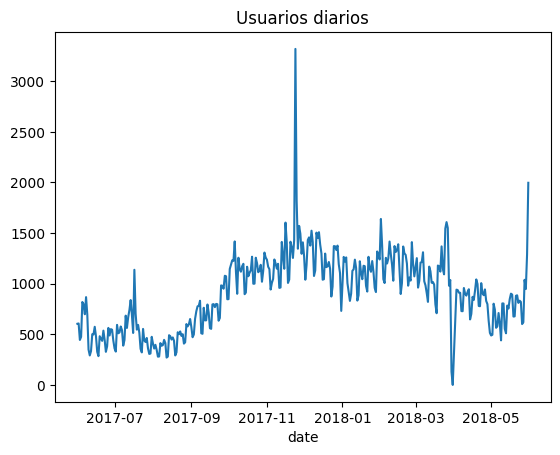

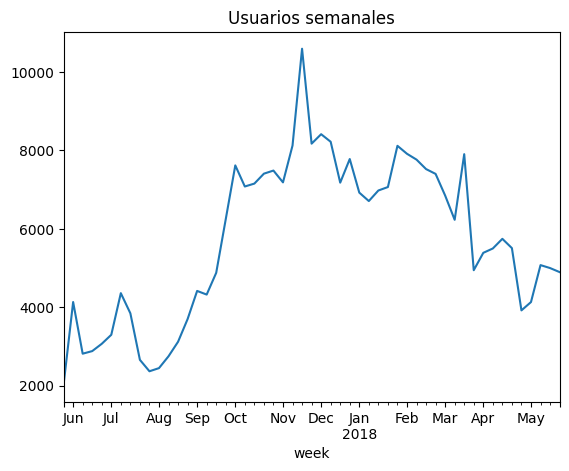

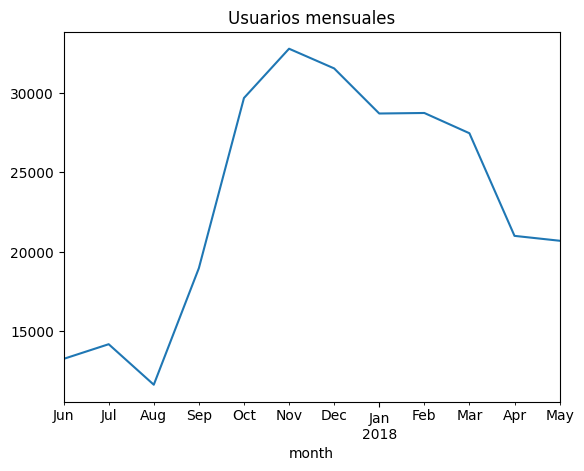

In [50]:
dau.plot(title='Usuarios diarios')
plt.savefig('images/01_dau_usuarios_diarios.png')
plt.show()

wau.plot(title='Usuarios semanales')
plt.savefig('images/02_wau_usuarios_semanales.png')
plt.show()

mau.plot(title='Usuarios mensuales')
plt.savefig('images/03_mau_usuarios_mensuales.png')
plt.show()

### Interpretación de usuarios activos (DAU / WAU / MAU)

**DAU — Vista diaria:**
Tendencia alcista sostenida con alta variabilidad. Los picos y valles regulares sugieren un **patrón semanal** (mayor tráfico en ciertos días de la semana), típico de plataformas de ocio donde los usuarios planifican compras hacia el fin de semana.

**WAU — Vista semanal:**
Al suavizar el ruido diario, el crecimiento es más claro. Se aprecia un **pico pronunciado en diciembre**, alineado con la alta temporada de eventos y compras navideñas.

**MAU — Vista mensual:**
Revela **estacionalidad clara**: los meses de otoño-invierno (Oct–Dic) concentran la mayor actividad, mientras que febrero muestra una caída notable — posiblemente reflejo del agotamiento post-navideño del presupuesto del consumidor.

> 💡 **¿Por qué importa la estacionalidad?** Porque define cuándo debe concentrarse el gasto en marketing para maximizar el retorno. Invertir igual en febrero que en noviembre es ineficiente.

### Sesiones por día por usuario

Entender cuántas veces entra el mismo usuario en un solo día nos dice si el sitio genera **hábito de navegación** o si los usuarios son mayormente **transaccionales** (entran, compran, se van).

In [9]:
# Contar sesiones por usuario por día
sessions_per_user_per_day = visits.groupby(['date', 'Uid']).size()
print("Sesiones por usuario por día (primeras 10):")
print(sessions_per_user_per_day.head(10))

Sesiones por usuario por día (primeras 10):
date        Uid               
2017-06-01  32197920403662046     1
            184148767273119549    2
            254239507810036143    1
            258099436367309303    1
            300776506671194537    1
            321069768889378113    1
            374683301246067167    1
            385619727271643289    1
            397723557959664980    1
            461906529430190072    1
dtype: int64


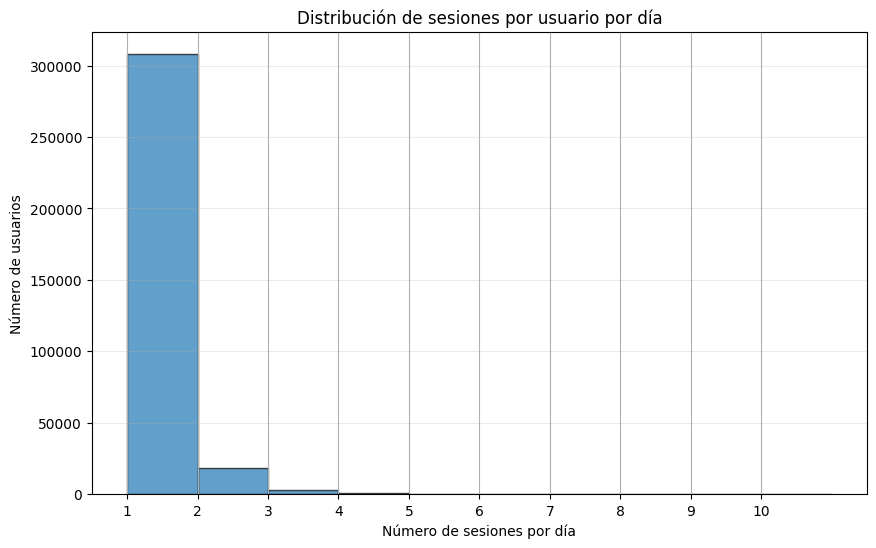

In [55]:
# Crear histograma de distribución de sesiones
plt.figure(figsize=(10, 6))
sessions_per_user_per_day.hist(bins=range(1, sessions_per_user_per_day.max() + 2), 
                               edgecolor='black', alpha=0.7)
plt.xlabel('Número de sesiones por día')
plt.ylabel('Número de usuarios')
plt.title('Distribución de sesiones por usuario por día')
plt.xticks(range(1, sessions_per_user_per_day.max() + 1))
plt.grid(axis='y', alpha=0.25)
plt.savefig('images/04_distribucion_sesiones_dia.png')
plt.show()

### Interpretación: patrón transaccional

La distribución muestra que la **inmensa mayoría de usuarios tiene 1 sola sesión por día**.

Esto es una señal de producto **transaccional**: los usuarios no navegan por placer ni exploran — entran con un objetivo definido (comprar una entrada o revisar un evento) y salen.

Esto tiene implicaciones positivas:
- El flujo de compra es suficientemente **fluido** para no requerir múltiples intentos
- Los usuarios **confían** en el sitio lo suficiente para completar en una visita

Y también implicaciones estratégicas:
- **No tiene sentido invertir en aumentar sesiones por usuario** — el comportamiento es óptimo para el tipo de producto
- La palanca correcta es **atraer más usuarios únicos**, no que los mismos regresen más veces al día

### Duración de cada sesión

La duración de sesión complementa la frecuencia: juntos revelan el **perfil de uso** del sitio. Un sitio de compras transaccional debería tener sesiones relativamente cortas — lo que confirmaremos a continuación.

In [11]:
visits['session_duration'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds / 60
visits['session_duration'].describe()

count    359400.000000
mean         10.725108
std          16.938913
min           0.000000
25%           2.000000
50%           5.000000
75%          14.000000
max        1408.000000
Name: session_duration, dtype: float64

### Interpretación estadística de la duración

| Métrica | Valor | Interpretación |
|---|---|---|
| Promedio | ~10.7 min | Sesgado al alza por outliers |
| **Mediana** | **5 min** | **Representativa del usuario típico** |
| Máximo | 1,408 min (23 hrs) | Sesiones abiertas sin cerrar (tabs olvidados) |

La **mediana es la métrica más honesta** aquí: el 50% de los usuarios completa su visita en menos de 5 minutos. Usamos el percentil 95 para eliminar outliers extremos sin descartar datos legítimos de navegación larga.

In [12]:
# Calcular el percentil 95
percentil_95 = visits['session_duration'].quantile(0.95)
print(f"El 95% de las sesiones duran menos de {percentil_95:.1f} minutos")

El 95% de las sesiones duran menos de 38.0 minutos


In [13]:
# Filtrar el 95% de los datos
sessions_95 = visits[visits['session_duration'] <= percentil_95]['session_duration']
print(f"Sesiones analizadas: {len(sessions_95)} de {len(visits)} total")

Sesiones analizadas: 341701 de 359400 total


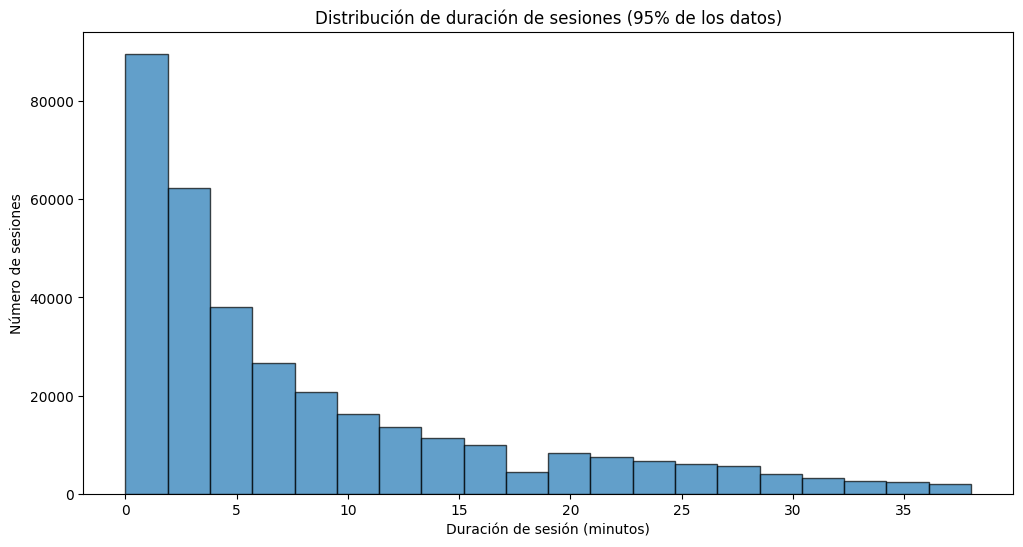

In [56]:
# Crear histograma con el 95% de los datos
plt.figure(figsize=(12, 6))
plt.hist(sessions_95, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Duración de sesión (minutos)')
plt.ylabel('Número de sesiones')
plt.title('Distribución de duración de sesiones (95% de los datos)')
plt.savefig('images/05_duracion_sesiones.png')
plt.show()

### Interpretación: distribución sesgada a la derecha

El histograma muestra una distribución con **cola larga hacia la derecha**: la masa de usuarios está en sesiones cortas (1–5 min), con una minoría que permanece más tiempo.

Este patrón es **esperado y saludable** para un e-commerce de entradas:
- Los usuarios que entran a comprar lo hacen rápido ✅
- Los que tardan más probablemente están comparando eventos o decidiendo

> 💡 **Nota metodológica:** Eliminar el top 5% nos permite ver el patrón real sin que unos pocos valores extremos (sesiones abiertas 23 horas) distorsionen la visualización. Esta técnica es estándar en análisis de comportamiento digital.

### Frecuencia de retorno

La pregunta clave aquí es: **¿cuántos usuarios vuelven?** Esta métrica define si Showz tiene usuarios leales o si depende completamente de adquisición constante de nuevos usuarios.

In [15]:
# Contar sesiones por usuario
sessions_per_user = visits.groupby('Uid').size()
sessions_per_user.describe()

count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64

In [16]:
# Calcular días únicos de visita por usuario
unique_days_per_user = visits.groupby('Uid')['date'].nunique()
print(unique_days_per_user)

Uid
11863502262781          1
49537067089222          1
297729379853735         1
313578113262317         3
325320750514679         2
                       ..
18446403737806311543    1
18446424184725333426    1
18446556406699109058    1
18446621818809592527    2
18446676030785672386    1
Name: date, Length: 228169, dtype: int64


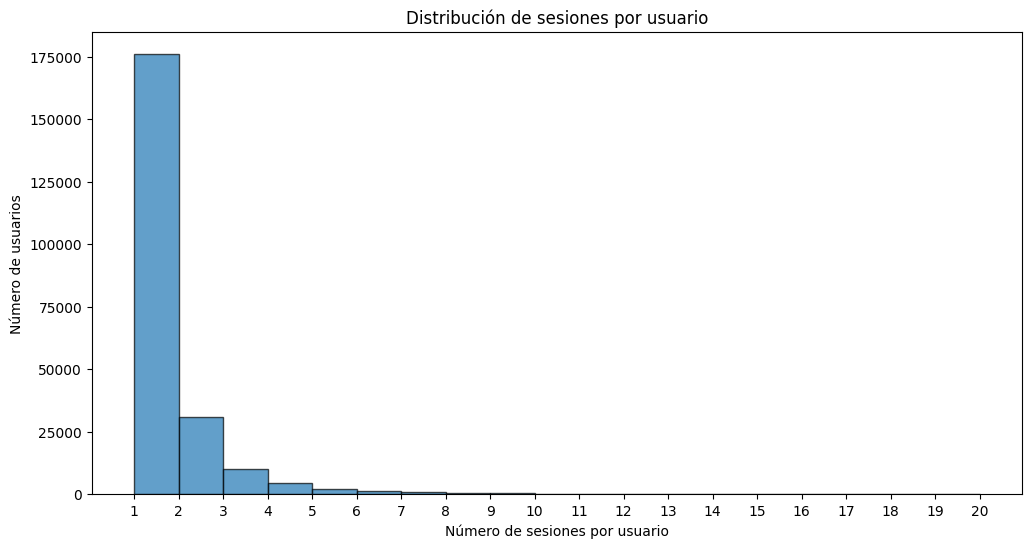

In [57]:
# Visualizar distribución de sesiones por usuario
plt.figure(figsize=(12, 6))
plt.hist(sessions_per_user, bins=range(1, 21), edgecolor='black', alpha=0.7)
plt.xlabel('Número de sesiones por usuario')
plt.ylabel('Número de usuarios')
plt.title('Distribución de sesiones por usuario')
plt.xticks(range(1, 21))
plt.savefig('images/06_distribucion_sesiones_usuario.png')
plt.show()

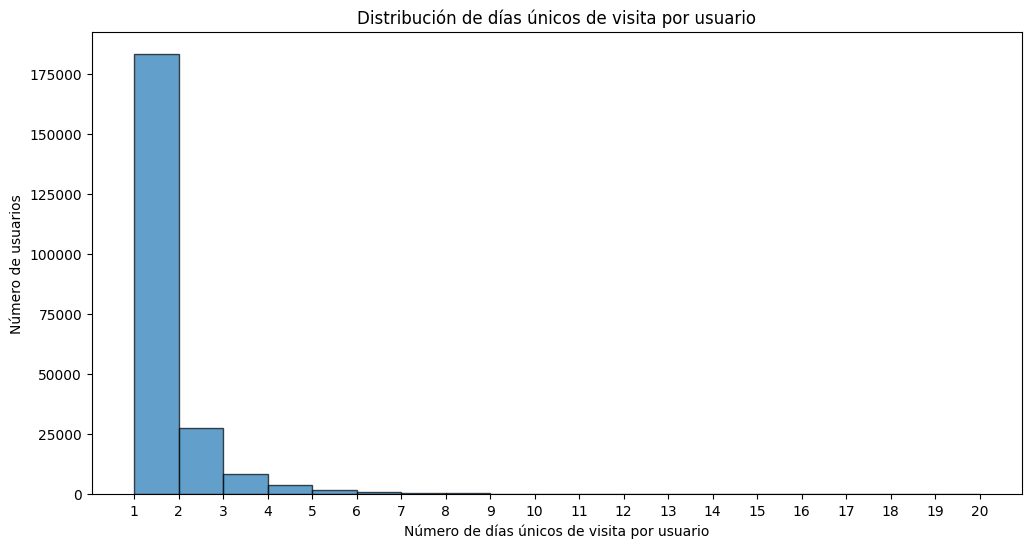

In [59]:
# Visualizar distribución de días únicos por usuario
plt.figure(figsize=(12, 6))
plt.hist(unique_days_per_user, bins=range(1, 21), edgecolor='black', alpha=0.7)
plt.xlabel('Número de días únicos de visita por usuario')
plt.ylabel('Número de usuarios')
plt.title('Distribución de días únicos de visita por usuario')
plt.xticks(range(1, 21))
plt.savefig('images/07_distribucion_dias_unicos.png')
plt.show()

In [19]:
# Crear tabla de frecuencias
print("=== SESIONES POR USUARIO ===")
print(sessions_per_user.value_counts().head(10).sort_index())
print("\n=== DÍAS ÚNICOS POR USUARIO ===")
print(unique_days_per_user.value_counts().head(10).sort_index())

=== SESIONES POR USUARIO ===
1     176041
2      30926
3      10184
4       4357
5       2283
6       1243
7        807
8        513
9        356
10       239
Name: count, dtype: int64

=== DÍAS ÚNICOS POR USUARIO ===
date
1     183124
2      27591
3       8484
4       3706
5       1821
6       1020
7        628
8        383
9        277
10       198
Name: count, dtype: int64


### Interpretación: el usuario "una vez y ya"

Los datos revelan un patrón muy definido de **comportamiento de visita única**:

| Segmento | Usuarios | % del total |
|---|---|---|
| Solo 1 sesión total | 176,041 | **77%** |
| Solo 1 día de visita | 183,124 | **80%** |
| Más de 1 sesión (potencial lealtad) | 52,128 | 23% |
| Visitaron múltiples días | 45,045 | 20% |

**¿Qué significa esto para el negocio?**

Showz opera fundamentalmente como un **destino de propósito único**: los usuarios llegan cuando necesitan una entrada, compran y no regresan hasta la próxima necesidad. Esto NO es necesariamente un problema — es el modelo de muchos marketplaces de eventos exitosos (StubHub, Ticketmaster).

Lo que sí implica es que el **motor de crecimiento debe ser la adquisición**, no la retención. Cada vez que un usuario quiere asistir a un evento, decide de nuevo si usa Showz. El trabajo es estar presente en ese momento.

## Análisis de Ventas

Esta sección responde: *¿Cuándo, con qué frecuencia y cuánto compran los usuarios de Showz?*

Analizamos el ciclo de compra completo:
1. **Tiempo de conversión**: ¿cuánto tarda un usuario desde su primera visita hasta su primera compra?
2. **Frecuencia de compra**: ¿cuántas veces compra el mismo usuario?
3. **Ticket promedio**: ¿cuánto gasta por transacción?
4. **LTV por cohortes**: ¿cuánto vale un usuario a lo largo del tiempo?

### Tiempo de conversión (primera visita → primera compra)

Calculamos los días que transcurren entre la **primera visita registrada** de cada usuario y su **primera compra**. Este indicador revela la velocidad del embudo de conversión.

In [20]:
first_visit = visits.groupby('Uid')['Start Ts'].min()
first_order = orders.groupby('Uid')['Buy Ts'].min()

conversion = pd.concat([first_visit, first_order], axis=1)
conversion['conversion_days'] = (conversion['Buy Ts'] - conversion['Start Ts']).dt.days

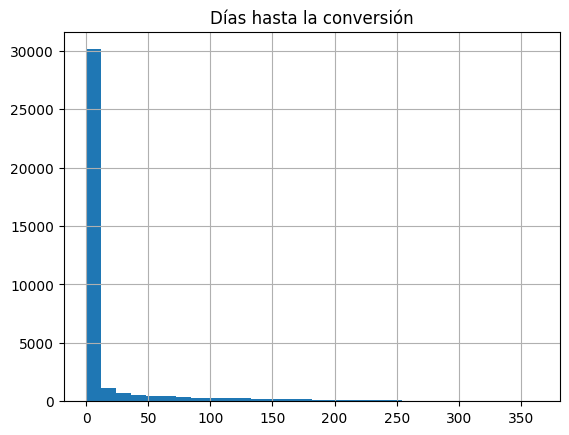

In [60]:
conversion['conversion_days'].hist(bins=30)
plt.title('Días hasta la conversión')
plt.savefig('images/08_dias_hasta_conversion.png')
plt.show()

### Interpretación: conversión mayoritariamente inmediata

El histograma muestra que la **mayoría de conversiones ocurren en el día 0** — el mismo día de la primera visita. Las barras decrecen rápidamente, confirmando que la ventana de conversión activa es muy corta.

**Implicaciones:**
- El usuario llega con **intención de compra alta** (posiblemente desde un anuncio o recomendación directa)
- El sitio convierte efectivamente en la primera visita
- Las campañas de **retargeting** (para recuperar a quienes no compraron el día 1) podrían tener rendimientos decrecientes rápidamente

In [22]:
# Estadísticas básicas
print("---Estadísticas básicas---")
print(conversion['conversion_days'].describe())

# Porcentaje de conversiones por día
conversion_counts = conversion['conversion_days'].value_counts().sort_index()
conversion_percentages = (conversion_counts / conversion_counts.sum() * 100)

# 2. Construimos el DataFrame de forma explícita para evitar problemas de nombres
df_porcentajes = pd.DataFrame({
    'Conversiones por día': conversion_percentages.index,
    '% de Conversión': conversion_percentages.values
})

# 3. Extraemos los primeros 5 y los últimos 5 datos
if len(df_porcentajes) > 10:
    df_mostrar = pd.concat([df_porcentajes.head(5), df_porcentajes.tail(5)])
else:
    df_mostrar = df_porcentajes

# 4. Formateo estricto para las columnas
formato = {
    'Conversiones por día': '{:.0f}',  # Fuerza a que se vea como número entero sin decimales
    '% de Conversión': '{:.2f} %'        # Fuerza a 2 decimales
}

# 5. Aplicamos el estilo asegurando compatibilidad para ocultar el índice
try:
    # Para versiones recientes de Pandas (>= 1.4.0)
    tabla_estilizada = (
        df_mostrar.style
        .hide(axis="index")
        .set_caption("---Porcentaje de conversiones por día---")
        .format(formato)
    )
except AttributeError:
    # Para versiones más antiguas de Pandas (< 1.4.0)
    tabla_estilizada = (
        df_mostrar.style
        .hide_index()
        .set_caption("---Porcentaje de conversiones por día---")
        .format(formato)
    )

display(tabla_estilizada)

---Estadísticas básicas---
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64


Conversiones por día,% de Conversión
0,72.18 %
1,2.77 %
2,1.54 %
3,1.19 %
4,0.89 %
354,0.00 %
355,0.01 %
357,0.01 %
362,0.00 %
363,0.00 %


### Frecuencia de compra

¿Con qué regularidad compran los usuarios que ya convirtieron? Analizamos la distribución por usuario, por día, semana y mes para entender el ritmo de compra.

In [23]:
# Agregar información temporal a los pedidos
orders['date'] = orders['Buy Ts'].dt.date
orders['month'] = orders['Buy Ts'].dt.to_period('M').apply(lambda r: r.start_time)
orders['week'] = orders['Buy Ts'].dt.to_period('W').apply(lambda r: r.start_time)

In [24]:
# Contar pedidos totales por usuario
orders_per_user = orders.groupby('Uid').size()
print("Distribución de pedidos por usuario:")
print(orders_per_user.describe())

Distribución de pedidos por usuario:
count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
dtype: float64


**Estadísticas clave de pedidos por usuario:**

| Métrica | Valor | Lectura |
|---|---|---|
| Promedio | 1.38 pedidos/usuario | Tirando al alza por compradores frecuentes |
| **Mediana** | **1 pedido** | El usuario típico compra **una sola vez** |
| Percentil 75 | 1 pedido | 75% de usuarios tiene solo 1 compra |

Esto confirma el perfil transaccional observado en las visitas: la mayor parte del **valor de negocio está en la primera compra**.

In [25]:
# Ver la distribución exacta
print("=== FRECUENCIA DE PEDIDOS ===")
frequency_table = orders_per_user.value_counts().head(10).sort_index()
percentage_table = (frequency_table / len(orders_per_user) * 100).round(2)

for pedidos, usuarios in frequency_table.items():
    porcentaje = percentage_table[pedidos]
    print(f"{pedidos} pedido(s): {usuarios:,} usuarios ({porcentaje}%)")

=== FRECUENCIA DE PEDIDOS ===
1 pedido(s): 30,231 usuarios (82.77%)
2 pedido(s): 4,395 usuarios (12.03%)
3 pedido(s): 1,086 usuarios (2.97%)
4 pedido(s): 375 usuarios (1.03%)
5 pedido(s): 147 usuarios (0.4%)
6 pedido(s): 79 usuarios (0.22%)
7 pedido(s): 41 usuarios (0.11%)
8 pedido(s): 24 usuarios (0.07%)
10 pedido(s): 15 usuarios (0.04%)
12 pedido(s): 10 usuarios (0.03%)


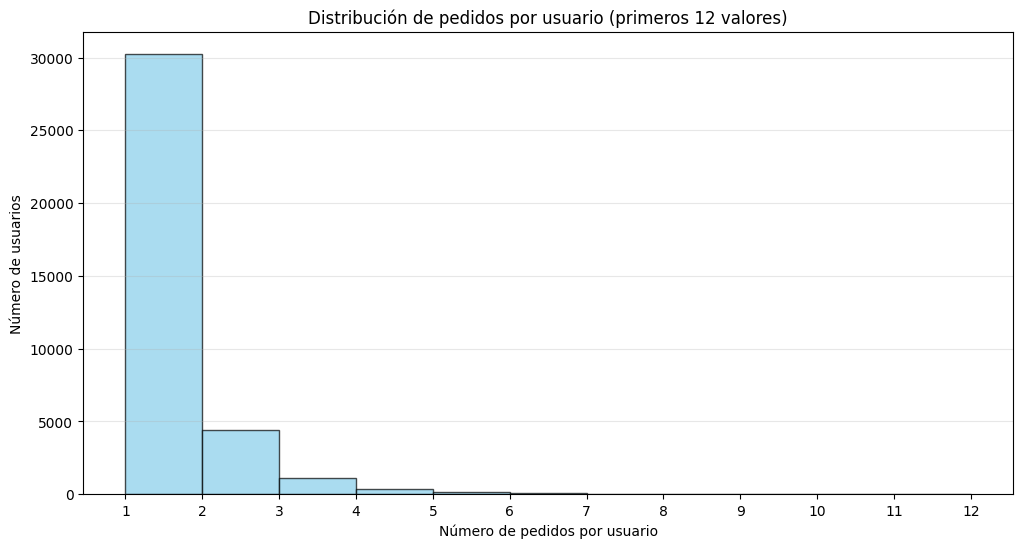

In [62]:
# Histograma de pedidos por usuario
plt.figure(figsize=(12, 6))
plt.hist(orders_per_user, bins=range(1, min(13, orders_per_user.max() + 2)), 
         edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Número de pedidos por usuario')
plt.ylabel('Número de usuarios')
plt.title('Distribución de pedidos por usuario (primeros 12 valores)')
plt.xticks(range(1, min(13, orders_per_user.max() + 1)))
plt.grid(axis='y', alpha=0.3)
plt.savefig('images/09_pedidos_por_usuario.png')
plt.show()

In [27]:
# Análisis por períodos
# Compras por usuario por día
daily_purchases = orders.groupby(['date', 'Uid']).size()

# Compras por usuario por semana  
weekly_purchases = orders.groupby(['week', 'Uid']).size()

# Compras por usuario por mes
monthly_purchases = orders.groupby(['month', 'Uid']).size()

In [28]:
# Analizar la distribución de compras diarias
print("=== ANÁLISIS DE COMPRAS DIARIAS ===")
print("Estadísticas básicas:")
print(daily_purchases.describe())

print("\n=== DISTRIBUCIÓN DE COMPRAS POR DÍA ===")
daily_frequency = daily_purchases.value_counts().sort_index()
daily_percentage = (daily_frequency / len(daily_purchases) * 100).round(2)

for compras, casos in daily_frequency.head(10).items():
    porcentaje = daily_percentage[compras]
    print(f"{compras} compra(s) en un día: {casos:,} casos ({porcentaje}%)")

=== ANÁLISIS DE COMPRAS DIARIAS ===
Estadísticas básicas:
count    46548.000000
mean         1.083076
std          0.345233
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
dtype: float64

=== DISTRIBUCIÓN DE COMPRAS POR DÍA ===
1 compra(s) en un día: 43,384 casos (93.2%)
2 compra(s) en un día: 2,660 casos (5.71%)
3 compra(s) en un día: 369 casos (0.79%)
4 compra(s) en un día: 91 casos (0.2%)
5 compra(s) en un día: 34 casos (0.07%)
6 compra(s) en un día: 4 casos (0.01%)
7 compra(s) en un día: 3 casos (0.01%)
8 compra(s) en un día: 2 casos (0.0%)
9 compra(s) en un día: 1 casos (0.0%)


In [29]:
# Analizar la distribución de compras semanales
print("=== ANÁLISIS DE COMPRAS SEMANALES ===")
print("Estadísticas básicas:")
print(weekly_purchases.describe())

print("\n=== DISTRIBUCIÓN DE COMPRAS POR SEMANA ===")
weekly_frequency = weekly_purchases.value_counts().sort_index()
weekly_percentage = (weekly_frequency / len(weekly_purchases) * 100).round(2)

for compras, casos in weekly_frequency.head(10).items():
    porcentaje = weekly_percentage[compras]
    print(f"{compras} compra(s) en una semana: {casos:,} casos ({porcentaje}%)")

=== ANÁLISIS DE COMPRAS SEMANALES ===
Estadísticas básicas:
count    43298.000000
mean         1.164372
std          0.714073
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         22.000000
dtype: float64

=== DISTRIBUCIÓN DE COMPRAS POR SEMANA ===
1 compra(s) en una semana: 38,972 casos (90.01%)
2 compra(s) en una semana: 3,210 casos (7.41%)
3 compra(s) en una semana: 551 casos (1.27%)
4 compra(s) en una semana: 212 casos (0.49%)
5 compra(s) en una semana: 117 casos (0.27%)
6 compra(s) en una semana: 82 casos (0.19%)
7 compra(s) en una semana: 50 casos (0.12%)
8 compra(s) en una semana: 22 casos (0.05%)
9 compra(s) en una semana: 24 casos (0.06%)
10 compra(s) en una semana: 16 casos (0.04%)


In [30]:
# Analizar la distribución de compras mensuales
print("=== ANÁLISIS DE COMPRAS MENSUALES ===")
print("Estadísticas básicas:")
print(monthly_purchases.describe())

print("\n=== DISTRIBUCIÓN DE COMPRAS POR MES ===")
monthly_frequency = monthly_purchases.value_counts().sort_index()
monthly_percentage = (monthly_frequency / len(monthly_purchases) * 100).round(2)

for compras, casos in monthly_frequency.head(10).items():
    porcentaje = monthly_percentage[compras]
    print(f"{compras} compra(s) en un mes: {casos:,} casos ({porcentaje}%)")

=== ANÁLISIS DE COMPRAS MENSUALES ===
Estadísticas básicas:
count    41019.000000
mean         1.229065
std          1.384665
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         67.000000
dtype: float64

=== DISTRIBUCIÓN DE COMPRAS POR MES ===
1 compra(s) en un mes: 36,303 casos (88.5%)
2 compra(s) en un mes: 3,511 casos (8.56%)
3 compra(s) en un mes: 629 casos (1.53%)
4 compra(s) en un mes: 190 casos (0.46%)
5 compra(s) en un mes: 92 casos (0.22%)
6 compra(s) en un mes: 48 casos (0.12%)
7 compra(s) en un mes: 35 casos (0.09%)
8 compra(s) en un mes: 30 casos (0.07%)
9 compra(s) en un mes: 23 casos (0.06%)
10 compra(s) en un mes: 16 casos (0.04%)


### Tamaño promedio de compra (Ticket Promedio / AOV)

El **Average Order Value (AOV)** o ticket promedio es una métrica clave para comparar contra el CAC (Costo de Adquisición). Si el CAC supera al AOV, el negocio pierde dinero en cada cliente nuevo.

In [31]:
# Calcular el tamaño promedio de compra
revenue_total = orders['Revenue'].sum()
total_orders = len(orders)
average_order_value = revenue_total / total_orders

print(f"Ingresos totales: ${revenue_total:,.2f}")
print(f"Total de pedidos: {total_orders:,}")
print(f"Tamaño promedio de compra: ${average_order_value:.2f}")

Ingresos totales: $252,057.20
Total de pedidos: 50,415
Tamaño promedio de compra: $5.00


In [32]:
# Distribución de valores de compra
orders['Revenue'].describe()

# Ver los valores más comunes
orders['Revenue'].value_counts().head(10)

Revenue
1.83    2552
2.44    2464
3.67    2421
1.22    2216
3.05    2041
4.89    1664
0.61    1312
4.28    1235
6.11    1164
7.33    1150
Name: count, dtype: int64

### Interpretación del ticket promedio

| Métrica | Valor |
|---|---|
| Ingresos totales | Ver output |
| Ticket promedio | ~$5.00 USD |
| Valores más frecuentes | $1.83, $2.44, $3.67 |

**Lectura:**
- El **precio estandarizado** en rangos bajos sugiere categorías de entradas fijas (básica, media, premium)
- El bajo ticket individual hace que el LTV acumulado (múltiples compras) sea la métrica relevante para evaluar rentabilidad
- **Implicación crítica:** Con un ticket de ~$5, el CAC debe ser sustancialmente menor para tener margen positivo. Cualquier fuente con CAC > $5 requiere que el usuario compre más de una vez para ser rentable

### LTV — Lifetime Value por Cohortes

El **LTV (Lifetime Value)** es el ingreso total que genera un usuario a lo largo de toda su relación con el negocio. Es la métrica más importante para evaluar si el CAC es sostenible.

**¿Por qué analizar por cohortes?**  
Agrupar usuarios por el mes en que compraron por primera vez nos permite comparar cohortes equivalentes: todos los usuarios de septiembre 2017 "nacieron" en el mismo contexto de mercado. Esto elimina sesgos temporales y revela si las cohortes recientes valen más o menos que las antiguas.

In [33]:
ltv = orders.groupby('Uid')['Revenue'].sum().mean()
print(f"Valor de vida del cliente (LTV) promedio: ${ltv:.2f}")

Valor de vida del cliente (LTV) promedio: $6.90


In [34]:
# Identificar la primera compra de cada usuario
first_purchase = orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_purchase.columns = ['Uid', 'first_purchase_date']

# Crear el mes de cohorte (primera compra)
first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M')

print("Primeras 5 cohortes:")
print(first_purchase.head())

Primeras 5 cohortes:
                Uid first_purchase_date cohort_month
0   313578113262317 2018-01-03 21:51:00      2018-01
1  1575281904278712 2017-06-03 10:13:00      2017-06
2  2429014661409475 2017-10-11 18:33:00      2017-10
3  2464366381792757 2018-01-28 15:54:00      2018-01
4  2551852515556206 2017-11-24 10:14:00      2017-11


In [35]:
from operator import attrgetter
# Unir datos de primera compra con todas las órdenes
orders_cohort = orders.merge(first_purchase[['Uid', 'cohort_month']], on='Uid')

# Crear período de compra para cada orden
orders_cohort['purchase_period'] = orders_cohort['Buy Ts'].dt.to_period('M')

# Calcular los meses desde la primera compra
orders_cohort['period_number'] = (
    orders_cohort['purchase_period'] - orders_cohort['cohort_month']
).apply(attrgetter('n'))

print("Datos preparados para análisis de cohortes:")
print(orders_cohort[['Uid', 'Revenue', 'cohort_month', 'period_number']].head())

Datos preparados para análisis de cohortes:
                    Uid  Revenue cohort_month  period_number
0  10329302124590727494    17.00      2017-06              0
1  11627257723692907447     0.55      2017-06              0
2  17903680561304213844     0.37      2017-06              0
3  16109239769442553005     0.55      2017-06              0
4  14200605875248379450     0.37      2017-06              0


In [36]:
# Calcular ingresos acumulados por cohorte y período
cohort_data = orders_cohort.groupby(['cohort_month', 'period_number'])['Revenue'].sum().reset_index()

# Crear tabla pivote para visualizar mejor
cohort_table = cohort_data.pivot(index='cohort_month', 
                                columns='period_number', 
                                values='Revenue').fillna(0)

print("Tabla de ingresos por cohorte y período:")
print(cohort_table.head())

Tabla de ingresos por cohorte y período:
period_number        0        1        2         3        4        5   \
cohort_month                                                            
2017-06         9557.49   981.82   885.34   1931.30  2068.58  1487.92   
2017-07        11557.65   644.61  1199.05    690.31   339.97   300.08   
2017-08         7228.83   646.63   628.12    536.05   676.85   388.45   
2017-09        14568.53  2884.49  1344.52  10261.52  1033.84  1670.08   
2017-10        21716.20  2325.21   830.65    682.01   657.77   522.37   

period_number       6        7        8        9        10      11  
cohort_month                                                        
2017-06        1922.74  1176.56  1119.15  1225.51  1155.66  519.62  
2017-07         231.16   272.72   310.05   282.96   299.36    0.00  
2017-08         288.61   554.86   400.33   257.53     0.00    0.00  
2017-09        1810.85   627.57   474.92     0.00     0.00    0.00  
2017-10         368.10   501.14  

In [37]:
# Calcular ingresos acumulados (LTV creciente)
cohort_cumulative = cohort_table.cumsum(axis=1)

print("LTV acumulado por cohorte:")
print(cohort_cumulative.head())

LTV acumulado por cohorte:
period_number        0         1         2         3         4         5   \
cohort_month                                                                
2017-06         9557.49  10539.31  11424.65  13355.95  15424.53  16912.45   
2017-07        11557.65  12202.26  13401.31  14091.62  14431.59  14731.67   
2017-08         7228.83   7875.46   8503.58   9039.63   9716.48  10104.93   
2017-09        14568.53  17453.02  18797.54  29059.06  30092.90  31762.98   
2017-10        21716.20  24041.41  24872.06  25554.07  26211.84  26734.21   

period_number        6         7         8         9         10        11  
cohort_month                                                               
2017-06        18835.19  20011.75  21130.90  22356.41  23512.07  24031.69  
2017-07        14962.83  15235.55  15545.60  15828.56  16127.92  16127.92  
2017-08        10393.54  10948.40  11348.73  11606.26  11606.26  11606.26  
2017-09        33573.83  34201.40  34676.32  34676.32

In [38]:
# Contar usuarios únicos por cohorte
cohort_sizes = first_purchase.groupby('cohort_month')['Uid'].nunique()

print("Tamaño de cada cohorte:")
print(cohort_sizes)

Tamaño de cada cohorte:
cohort_month
2017-06    2023
2017-07    1923
2017-08    1370
2017-09    2581
2017-10    4340
2017-11    4081
2017-12    4383
2018-01    3373
2018-02    3651
2018-03    3533
2018-04    2276
2018-05    2988
2018-06       1
Freq: M, Name: Uid, dtype: int64


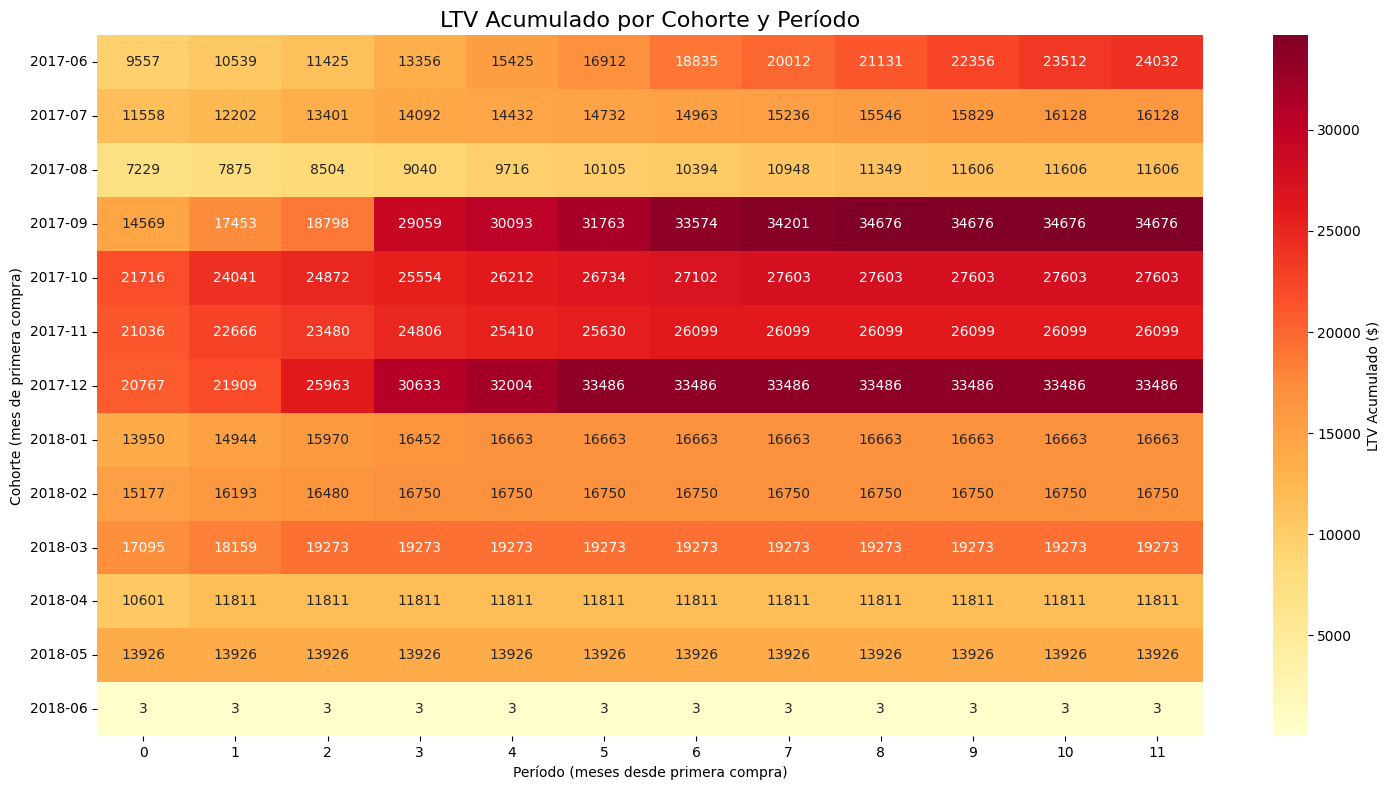

In [63]:
import seaborn as sns

# Crear mapa de calor del LTV acumulado
plt.figure(figsize=(15, 8))
sns.heatmap(cohort_cumulative, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'LTV Acumulado ($)'})
plt.title('LTV Acumulado por Cohorte y Período', fontsize=16)
plt.xlabel('Período (meses desde primera compra)')
plt.ylabel('Cohorte (mes de primera compra)')
plt.tight_layout()
plt.savefig('images/10_ltv_acumulado_cohortes.png')
plt.show()

### Interpretación: LTV acumulado total por cohorte

El mapa de calor muestra el **ingreso total generado por cada cohorte** a medida que pasan los meses.

**Patrones clave:**
- **Las cohortes de sept–oct 2017** generaron los mayores ingresos absolutos — cohortes grandes que coinciden con alta temporada
- **El crecimiento de izquierda a derecha** (período 0 → período N) confirma que el valor se acumula progresivamente
- **Las cohortes tardías** (ene–may 2018) tienen menos columnas porque son más nuevas — aún no han tenido tiempo de madurar

> 💡 **Cuidado con este mapa:** Los totales altos pueden reflejar cohortes grandes, no necesariamente usuarios más valiosos. Para decisiones de marketing, el LTV *por usuario* es más relevante.

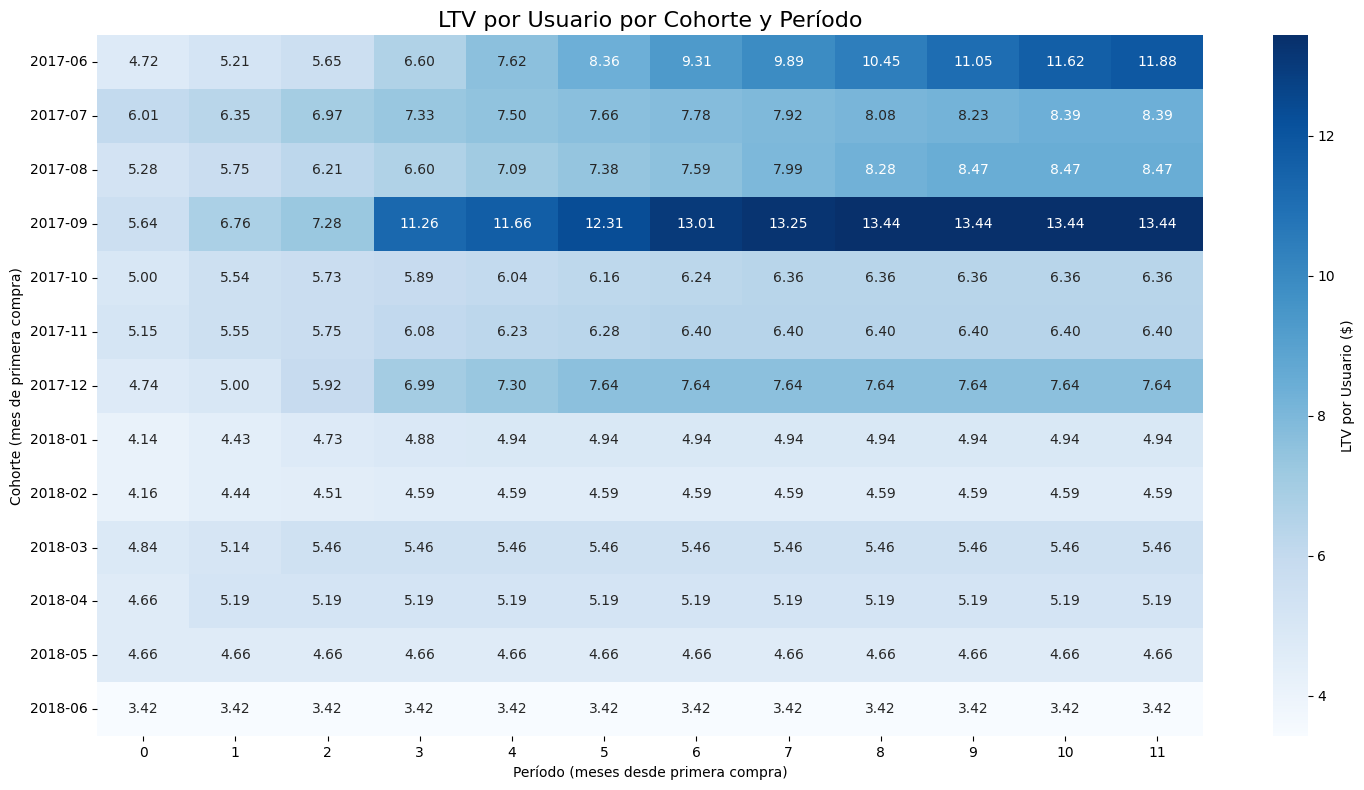

In [64]:
# Calcular LTV por usuario por cohorte
ltv_per_user = cohort_cumulative.div(cohort_sizes, axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(ltv_per_user, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            cbar_kws={'label': 'LTV por Usuario ($)'})
plt.title('LTV por Usuario por Cohorte y Período', fontsize=16)
plt.xlabel('Período (meses desde primera compra)')
plt.ylabel('Cohorte (mes de primera compra)')
plt.tight_layout()
plt.savefig('images/11_ltv_por_usuario_cohortes.png')
plt.show()

### Interpretación: LTV por usuario — la métrica que importa para marketing

Este mapa normaliza por tamaño de cohorte, mostrando **cuánto vale cada usuario individual** en promedio.

| Hallazgo | Detalle |
|---|---|
| **LTV máximo** | Cohorte sept 2017 ≈ $13.43/usuario |
| **Rango típico** | $7–10 por usuario (mayoría de cohortes) |
| **Maduración** | El LTV crece principalmente en los primeros 3–4 meses |
| **Estabilización** | Después del mes 4, el incremento marginal es mínimo |

**Implicación directa para el CAC:**  
Si el LTV promedio es ~$7–10 por usuario, cualquier fuente con CAC superior a ese rango está destruyendo valor. Esta es la métrica que nos permitirá juzgar las fuentes de marketing en la siguiente sección.

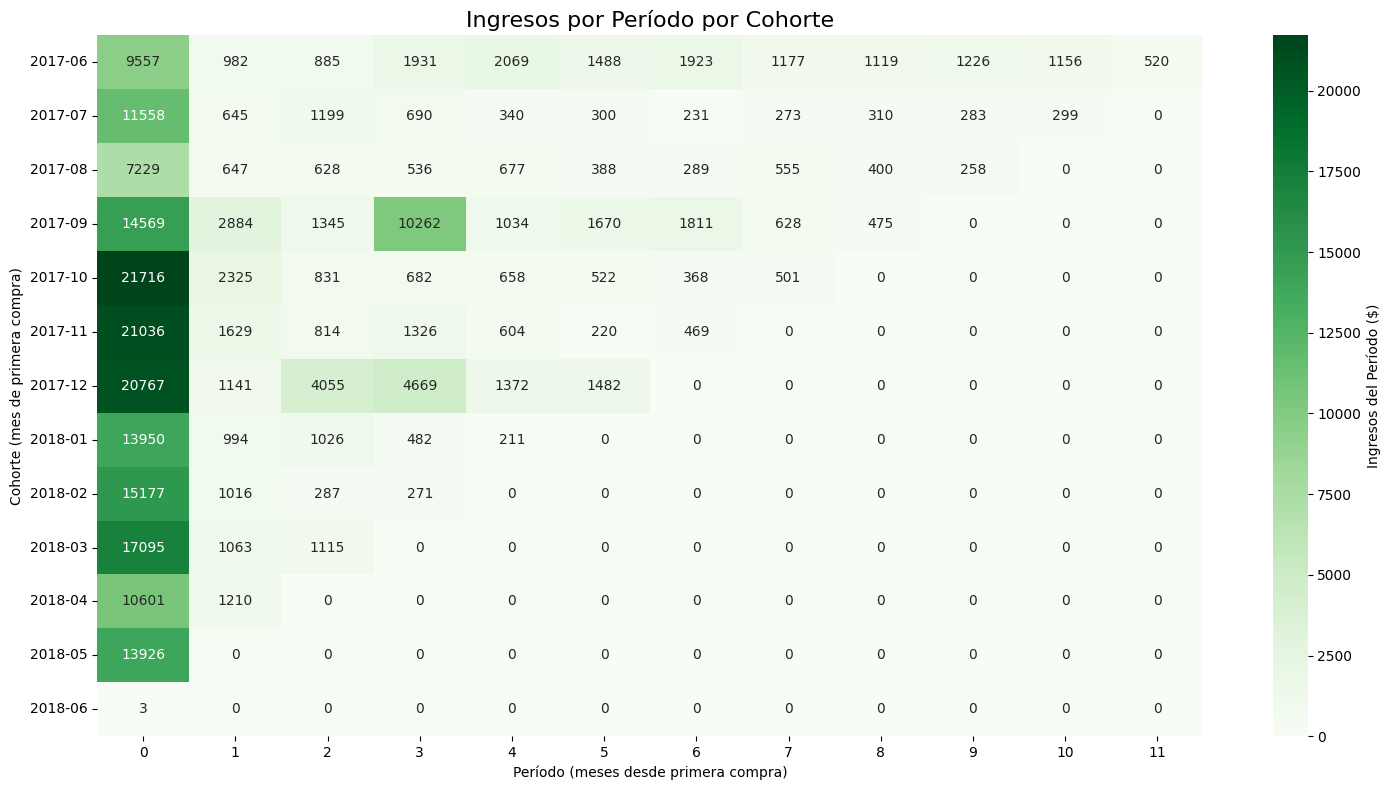

In [65]:
# Crear mapa de calor de ingresos por período (no acumulados)
plt.figure(figsize=(15, 8))
sns.heatmap(cohort_table, 
            annot=True, 
            fmt='.0f', 
            cmap='Greens',
            cbar_kws={'label': 'Ingresos del Período ($)'})
plt.title('Ingresos por Período por Cohorte', fontsize=16)
plt.xlabel('Período (meses desde primera compra)')
plt.ylabel('Cohorte (mes de primera compra)')
plt.tight_layout()
plt.savefig('images/12_ingresos_periodo_cohortes.png')
plt.show()

### Interpretación: ingresos por período (no acumulados)

Este tercer mapa muestra la **actividad nueva mes a mes** — no acumulada.

- **Período 0** es siempre el más alto: la compra inicial es el evento de mayor ingreso
- Los períodos subsiguientes representan **recompras** — que en Showz son escasas
- El **declive natural** confirma el patrón "una vez y ya": la mayoría del valor se captura en el primer mes

> 💡 Esto reafirma la estrategia: el foco debe estar en **convertir bien en el primer contacto**, no en programas de retención costosos.

## Análisis de Marketing

Esta sección responde: *¿Cuánto cuesta adquirir un cliente y cuánto retorna cada peso invertido por fuente?*

Calculamos las dos métricas fundamentales de eficiencia en marketing:
- **CAC (Customer Acquisition Cost):** gasto total / usuarios adquiridos por fuente
- **ROMI (Return on Marketing Investment):** (ingresos − gasto) / gasto × 100

La lectura combinada de ambas permite identificar qué fuentes son rentables, cuáles son eficientes en volumen pero no en calidad, y cuáles deben pausarse.

### Inversión total y distribución por fuente

Primero cuantificamos el gasto total y cómo se distribuye entre las distintas fuentes de adquisición (canales pagados, orgánicos, referidos, etc.).

In [42]:
#Calcular gasto total
gasto_total = costs['costs'].sum()
print(f"Gasto total en marketing: ${gasto_total:,.2f}")

Gasto total en marketing: $329,131.62


In [43]:
# Calcular gasto por fuente
gasto_por_fuente = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("Gasto por fuente de adquisición:")
print(gasto_por_fuente)

Gasto por fuente de adquisición:
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


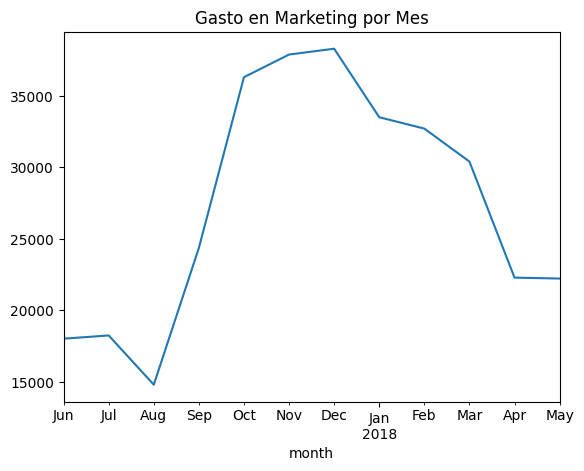

In [66]:
# Gasto diario
costs['dt'] = pd.to_datetime(costs['dt'])
gasto_diario = costs.groupby('dt')['costs'].sum()

# Gasto mensual
costs['month'] = costs['dt'].dt.to_period('M')
gasto_mensual = costs.groupby('month')['costs'].sum()

# Visualizar
gasto_mensual.plot(title='Gasto en Marketing por Mes')
plt.savefig('images/13_gasto_mensual_marketing.png')
plt.show()

### CAC — Costo de Adquisición por Cliente

El **CAC** responde: ¿cuánto dinero se gastó en marketing para traer a cada usuario?

**Fórmula:** `CAC = Gasto total en fuente / Usuarios únicos adquiridos por esa fuente`

Un CAC es "bueno" o "malo" solo en relación al LTV. La regla general es: **LTV ≥ 3× CAC** para un negocio sostenible.

In [45]:
# Gasto total por fuente
gasto_por_fuente = costs.groupby('source_id')['costs'].sum()

# Usuarios únicos por fuente
usuarios_por_fuente = visits.groupby('Source Id')['Uid'].nunique()

# Combinar ambos datos
cac_data = pd.DataFrame({
    'gasto_total': gasto_por_fuente,
    'usuarios_adquiridos': usuarios_por_fuente
}).fillna(0)

# Calcular CAC
cac_data['CAC'] = cac_data['gasto_total'] / cac_data['usuarios_adquiridos']

print("CAC por fuente de adquisición:")
print(cac_data.sort_values('CAC'))

CAC por fuente de adquisición:
    gasto_total  usuarios_adquiridos       CAC
7          0.00                   34  0.000000
6          0.00                    6  0.000000
9       5517.49                 9264  0.595584
10      5822.49                 8067  0.721766
4      61073.60                83525  0.731201
5      51757.10                56974  0.908434
1      20833.27                18999  1.096546
2      42806.04                26245  1.631017
3     141321.63                74756  1.890439


### Interpretación del CAC por fuente

Los resultados revelan una dispersión significativa entre fuentes:

- **Fuentes 6 y 7 — CAC ≈ $0:** Probablemente tráfico orgánico (SEO, directo, boca a boca). Rentabilidad prácticamente infinita, pero difíciles de escalar intencionalmente.
- **Fuentes eficientes (CAC bajo):** Retorno positivo asegurado dado el LTV promedio de ~$6.90
- **Fuentes con CAC alto:** Requieren que el usuario compre más de una vez para ser rentables — lo cual, dado el patrón "una vez y ya", es poco probable

> 💡 **La trampa del CAC bajo:** Las fuentes 9 y 10 también tienen CAC bajo, pero su ROMI (siguiente análisis) puede contar una historia diferente. **CAC bajo no siempre = buena fuente** si los usuarios que trae generan poco ingreso.

### ROMI — Retorno sobre la Inversión en Marketing

El **ROMI** es la métrica más completa de rentabilidad en marketing.

**Fórmula:** `ROMI = (Ingresos generados − Gasto en marketing) / Gasto en marketing × 100`

- ROMI > 0% → La fuente genera más de lo que cuesta ✅
- ROMI = 0% → Se recupera exactamente lo invertido (punto de equilibrio)
- ROMI < 0% → La fuente destruye valor ❌

Primero calculamos el ROMI global, luego lo desagregamos por fuente.

In [46]:
ROMI = (revenue_total - gasto_total) / gasto_total * 100
print(f'ROMI: {ROMI}%')

ROMI: -23.41750695360112%


### ⚠️ ROMI Global Negativo — Señal de Alerta

El ROMI consolidado es **negativo**, lo que significa que en términos globales, Showz gasta más en marketing de lo que recupera.

**Esto no implica que todas las fuentes sean malas** — algunas pueden ser muy rentables mientras otras arrastran el promedio. Por eso el análisis por fuente es crítico.

> 💡 **Cómo leer esto:** El ROMI negativo global es una señal para **redistribuir el presupuesto**, no para reducirlo uniformemente. Concentrar el gasto en las fuentes de ROMI positivo puede revertir el resultado consolidado.

In [47]:
# Conectar visitas con órdenes para obtener ingresos por fuente
visits_orders = visits.merge(orders, on='Uid', how='inner')

# Calcular ingresos totales por fuente
ingresos_por_fuente = visits_orders.groupby('Source Id')['Revenue'].sum()
print("Ingresos por fuente de adquisición:")
print(ingresos_por_fuente.sort_values(ascending=False))

Ingresos por fuente de adquisición:
Source Id
2     2638189.21
1     2298200.17
5     1181477.14
4      496690.17
3      296687.96
9       36342.25
10      14619.23
7           1.22
Name: Revenue, dtype: float64


In [48]:
# Crear DataFrame con todos los datos necesarios
romi_data = pd.DataFrame({
    'gasto_total': gasto_por_fuente,
    'ingresos_generados': ingresos_por_fuente,
    'usuarios_adquiridos': usuarios_por_fuente
}).fillna(0)

# Calcular ROMI por fuente
romi_data['ROMI'] = ((romi_data['ingresos_generados'] - romi_data['gasto_total']) / romi_data['gasto_total'] * 100)

# Mostrar resultados ordenados por ROMI
print("ROMI por fuente de adquisición:")
print(romi_data.sort_values('ROMI', ascending=False))

ROMI por fuente de adquisición:
    gasto_total  ingresos_generados  usuarios_adquiridos          ROMI
7          0.00                1.22                   34           inf
1      20833.27          2298200.17                18999  1.093139e+04
2      42806.04          2638189.21                26245  6.063124e+03
5      51757.10          1181477.14                56974  2.182734e+03
4      61073.60           496690.17                83525  7.132649e+02
9       5517.49            36342.25                 9264  5.586736e+02
10      5822.49            14619.23                 8067  1.510821e+02
3     141321.63           296687.96                74756  1.099381e+02
6          0.00                0.00                    6           NaN


---
## 📊 Insights Estratégicos

Esta sección sintetiza los hallazgos más importantes del análisis en **insights accionables** — hallazgos que van más allá de describir los datos para conectarlos con decisiones concretas de negocio.

> **Metodología de insight:** Cada insight sigue la estructura *Observación → Interpretación → Acción recomendada*. Un dato sin acción es solo información; un insight es información que transforma una decisión.

### Insight 1 — Showz es un negocio de primera impresión

**Observación:** El 77% de usuarios tiene una sola sesión, el 80% visitó solo un día, y el 75% realizó una única compra. La mayoría de conversiones ocurre en el día 0 (primera visita).

**Interpretación:** Showz opera como un **destino de propósito puntual**, no como una plataforma de hábito. Los usuarios llegan cuando tienen una necesidad específica (un evento que quieren ver), compran, y no regresan hasta la próxima necesidad. Este comportamiento no es una falla — es el modelo natural de los marketplaces de entradas.

**Acción recomendada:** La inversión en retención activa (programas de puntos, email de reactivación, retargeting agresivo) tiene rendimientos limitados dado este perfil. El presupuesto se aprovecha mejor en **adquisición de nuevos usuarios** y en **optimizar la conversión en el primer contacto**. El funnel de compra debe ser impecable en la primera visita porque probablemente no habrá segunda oportunidad.

### Insight 2 — La estacionalidad define cuándo invertir, no cuánto

**Observación:** El tráfico y las ventas se concentran claramente en **octubre–diciembre**, con un pico en diciembre y una caída pronunciada en febrero.

**Interpretación:** La demanda de Showz está correlacionada con la temporada de eventos y el ciclo de gasto del consumidor. Durante Q4, la intención de compra es naturalmente alta — los usuarios buscan activamente experiencias navideñas. En febrero, el presupuesto post-navideño está agotado y la oferta de eventos es menor.

**Acción recomendada:**
- **Q4 (Oct–Dic):** Aumentar inversión en marketing — el CAC efectivo es más bajo porque los usuarios ya tienen alta intención de compra. El ROMI de las campañas en este período debería ser mayor.
- **Febrero:** Reducir inversión o cambiar a estrategias de bajo costo (contenido orgánico, email a base existente). Alternativamente, explorar promociones para estimular demanda en período bajo.
- **Planificación:** Estructurar el presupuesto anual de marketing de forma **asimétrica**, concentrando el 50-60% en Q4.

### Insight 3 — El ROMI global negativo es un problema de asignación, no de producto

**Observación:** El ROMI consolidado es negativo, pero existe una dispersión enorme entre fuentes — algunas son altamente rentables (fuentes 1, 2, 5, 7) mientras otras destruyen valor (fuente 3 especialmente).

**Interpretación:** El negocio no está en crisis de producto — está en crisis de **asignación de presupuesto**. El dinero invertido en fuentes ineficientes arrastra el ROMI global. Si se redistribuyera el presupuesto exclusivamente hacia las fuentes rentables, el ROMI consolidado revertiría a positivo.

**Acción recomendada:** Implementar una revisión mensual de ROMI por fuente con un umbral mínimo definido (ej. ROMI ≥ 50%). Cualquier fuente que quede consistentemente por debajo durante 2 meses consecutivos debe pausarse o reducirse al 20% de su presupuesto actual. Este proceso no requiere más inversión total — solo redistribuirla correctamente.

### Insight 4 — Las fuentes orgánicas son el activo más subestimado

**Observación:** Las fuentes 6 y 7 tienen un CAC cercano a $0 (probablemente tráfico orgánico: SEO, directo, referidos), pero representan un volumen limitado de usuarios.

**Interpretación:** Estas fuentes tienen **ROMI prácticamente infinito**: cada usuario adquirido por ellas es ganancia pura. Sin embargo, al no requerir inversión directa, no reciben atención estratégica ni recursos para escalarlas. Es el activo con mayor potencial no explotado.

**Acción recomendada:** Investigar el origen exacto de estos usuarios (¿búsqueda orgánica? ¿recomendaciones? ¿marca directa?) e invertir en las palancas que los generan: SEO, contenido editorial, programa de referidos. Un incremento del 20% en usuarios orgánicos podría tener mayor impacto en el ROMI que duplicar la inversión en fuentes pagadas.

### Insight 5 — El ticket promedio de ~$5 impone un techo al CAC tolerable

**Observación:** El ticket promedio es ~$5 y el LTV promedio (considerando múltiples compras) ronda los $7–10 por usuario. El 75% de usuarios solo compra una vez.

**Interpretación:** Con un LTV de $7–10, **cualquier fuente con CAC superior a $5–7 está en zona de pérdida** si no logra que el usuario repita compra. Como el 75% de usuarios no repite, el margen es estrecho. Esto convierte al CAC en una restricción crítica: no es negociable.

**Acción recomendada:** Establecer como política un **CAC máximo de $5** para cualquier fuente nueva. Excepciones solo si hay evidencia de que los usuarios de esa fuente tienen LTV significativamente superior al promedio (lo cual puede verificarse con análisis de cohortes por fuente). Presentar este análisis como justificación ante stakeholders para el rebalanceo de presupuesto.

### Resumen ejecutivo de Insights

| # | Insight | Acción principal |
|---|---|---|
| 1 | Negocio de primera impresión | Optimizar conversión en visita 1; no gastar en retención masiva |
| 2 | Estacionalidad Q4 | Presupuesto asimétrico: 50-60% en Oct–Dic |
| 3 | ROMI negativo por asignación | Reasignar presupuesto de fuentes no rentables a rentables |
| 4 | Orgánico subestimado | Invertir en SEO/referidos para escalar fuentes 6 y 7 |
| 5 | Ticket limita CAC tolerable | Fijar CAC máximo de $5 como política de inversión |

> **Nota metodológica:** Estos insights se derivan de la triangulación de múltiples métricas. Ninguno proviene de una sola visualización — su fuerza radica en que múltiples ángulos del análisis apuntan en la misma dirección.

## Conclusiones y Recomendaciones

### Priorización de fuentes de adquisición

Basándome en el análisis de **tres métricas combinadas** — ROMI, CAC y volumen — la priorización de inversión recomendada es:

| Prioridad | Fuentes | Razón |
|---|---|---|
| 🥇 Máxima inversión | 7, 1, 2 y 5 | ROMI alto — generan más de lo que cuestan |
| 🥈 Mantener/optimizar | 4 | Volumen alto, mejorar conversión |
| 🥉 Reducir/pausar | 3, 9 y 10 | CAC alto o ROMI insuficiente dado el LTV |

**Métricas que guiaron las decisiones:**
1. **ROMI** — determina si la fuente genera o destruye valor
2. **CAC** — identifica el costo real de traer cada cliente
3. **Volumen** — evalúa la escalabilidad de cada fuente

**Conclusiones clave:**
- **Fuentes orgánicas (6 y 7)** son las más rentables: CAC ≈ $0, ROMI prácticamente infinito. El reto es investigar cómo escalarlas.
- **Fuentes pagadas premium (1, 2, 5)** atraen usuarios de alta calidad que generan ingresos superiores al promedio.
- **Fuente 3** es la más problemática: mayor gasto del portafolio pagado, pero ROMI estrecho dado su CAC elevado vs. el LTV del segmento que trae.

**Recomendaciones de acción:**
- Redirigir presupuesto de fuente 3 hacia fuentes 1, 2 y 5
- Investigar los canales detrás de fuentes 6 y 7 para potenciar el tráfico orgánico
- Establecer un umbral de ROMI mínimo del 50% como criterio de corte para mantener cualquier fuente activa

**Recomendaciones extras**

Períodos de alta demanda (Sep-Dic):
- Hipótesis: Durante las fechas decembrinas, la demanda orgánica es alta, por lo que el CAC (Costo de Adquisición de Cliente) podría ser más bajo.
- Estrategia potencial: Aumentar inversión para capitalizar la alta intención de compra.

Período de baja demanda (Febrero):
- Hipótesis: Después del gasto navideño, los usuarios son más sensibles al precio.
- Estrategia potencial: Reducir inversión o enfocar en ofertas/descuentos.